In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os 
import sys
import matplotlib.pyplot as plt
import pynapple as nap
import numpy as np
sys.path.append("..")

import hippocampalseq as hse
import hippocampalseq.preprocessing as hsep
import hippocampalseq.plotting as hsepl
import hippocampalseq.models as hsem 
import hippocampalseq.utils as hseu

In [3]:
time_window_ms = 20
time_window_s  = time_window_ms / 1000
time_window_advance_ms = 5#time_window_ms
time_window_advance_s = time_window_advance_ms / 1000
bin_size = 2

data_path = os.path.realpath("../data")
rat_name = "Janni"
session = 1
track_type = "Open"
results_path = f"../results/{rat_name}/{track_type}{session}"

In [4]:
(
    raw_position,
    running_position,
    raw_spikes,
    running_spike_info,
    running_spikes,
    ripple_intervals,
    excitatory_neurons,
    inhibitory_neurons,
) = hsep.load_clean_data(
    data_path=data_path,
    rat_name=rat_name,
    session=session,
    track_type=track_type,
    ripple_type="awake",
)

In [5]:
place_fields, place_cell_ids = hsep.calculate_placefields(
    running_position,
    running_spike_info,
    running_spikes,
    excitatory_neurons,
    environment_size=(0,0,200,200),
    #environment_size=None,
    track_type='Open',
    posterior=False,
    velocity_cutoff=10.0
)

[  1.   3.   5.   7.   9.  11.  13.  15.  17.  19.  21.  23.  25.  27.
  29.  31.  33.  35.  37.  39.  41.  43.  45.  47.  49.  51.  53.  55.
  57.  59.  61.  63.  65.  67.  69.  71.  73.  75.  77.  79.  81.  83.
  85.  87.  89.  91.  93.  95.  97.  99. 101. 103. 105. 107. 109. 111.
 113. 115. 117. 119. 121. 123. 125. 127. 129. 131. 133. 135. 137. 139.
 141. 143. 145. 147. 149. 151. 153. 155. 157. 159. 161. 163. 165. 167.
 169. 171. 173. 175. 177. 179. 181. 183. 185. 187. 189. 191. 193. 195.
 197. 199.]


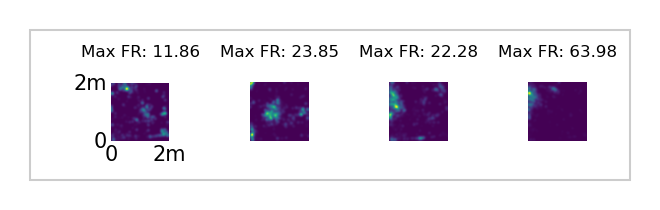

In [6]:
if place_fields.shape[-1] == 1:
    hsepl.plot_linear_placefields(None, place_fields, figsize=(8,8))
else:
    hsepl.plot_open_placefields(place_fields, pfs=[0,1,2,3])

In [7]:
true_trajectories, spikemats = hsep.process_theta(
    running_position,
    running_spikes,
    place_cell_ids,
    time_window_ms=time_window_ms,
    time_window_advance_ms=time_window_advance_ms,
    velocity_cutoff=10.0
)

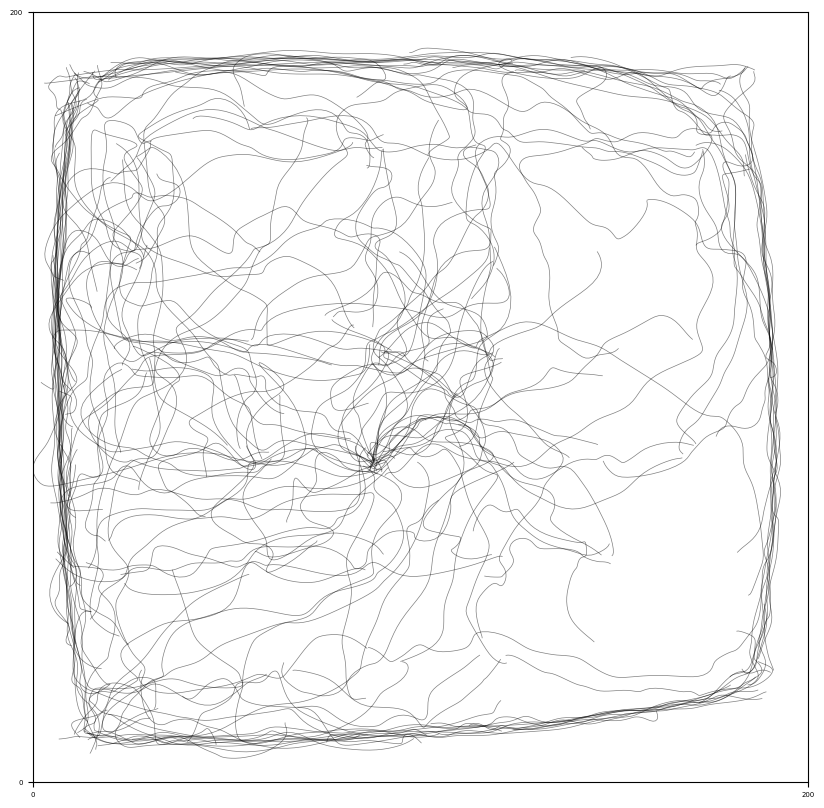

In [8]:
plt.figure(figsize=(10,10))
hsepl.plot_trajectories(true_trajectories)

In [9]:
decoder = hsem.BayesianMAP(place_fields, time_window_s, bin_size)
results = decoder.fit(spikemats,)
decoded_trajectory = results.trajectories
cum_prob = results.cumulative_probabilities

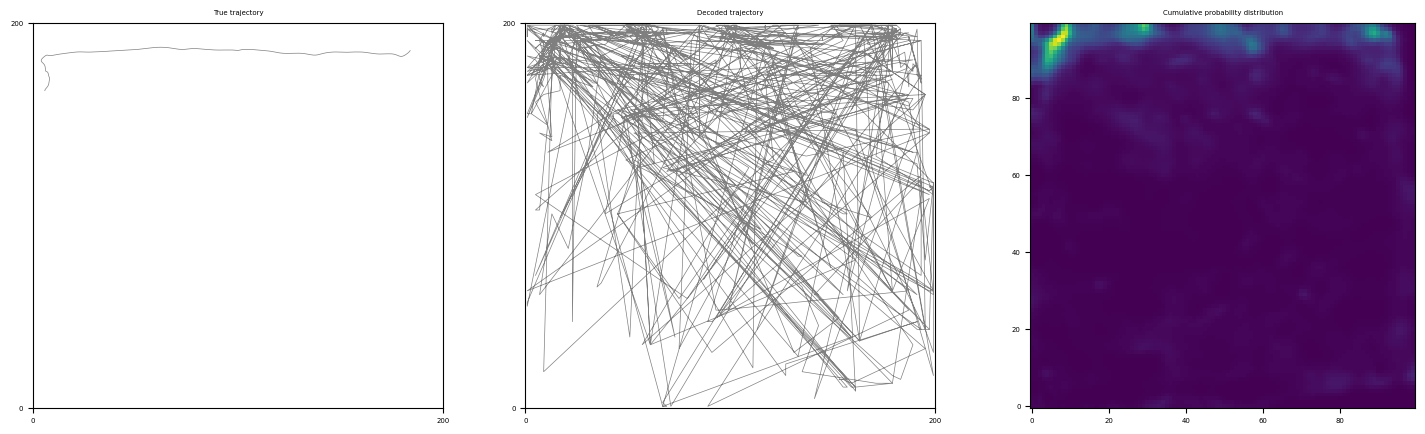

In [10]:
num = 76
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
plt.title("True trajectory")
hsepl.plot_trajectories([true_trajectories[num]])
plt.subplot(1,3,2)
plt.title("Decoded trajectory")
hsepl.plot_trajectories([decoded_trajectory[num]])
plt.subplot(1,3,3)
plt.title("Cumulative probability distribution")
plt.imshow(cum_prob[num], origin='lower')

In [11]:
ripple_spikemats = hsep.process_ripples(
    ripple_intervals,
    raw_spikes,
    place_cell_ids,
    3.0,
    3.0 
)

In [12]:
decoder = hsem.BayesianMAP(place_fields, time_window_s, bin_size)
results = decoder.fit(ripple_spikemats,)
decoded_trajectory = results.trajectories
cum_prob = results.cumulative_probabilities

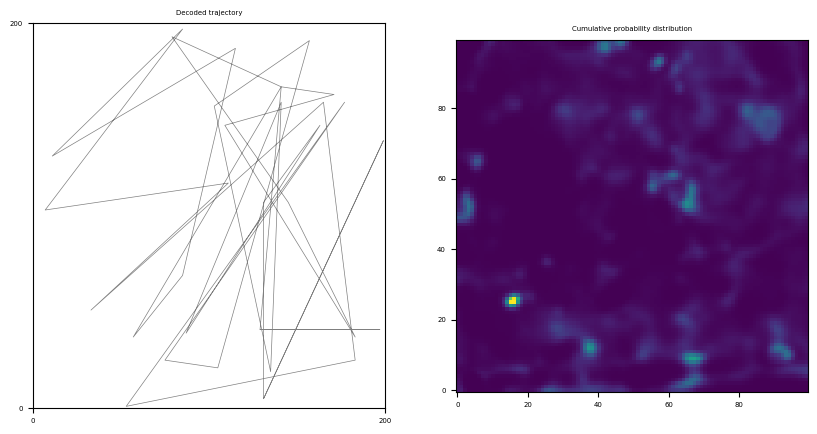

In [13]:
num = 10
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Decoded trajectory")
hsepl.plot_trajectories([decoded_trajectory[num]])
plt.subplot(1,2,2)
plt.title("Cumulative probability distribution")
plt.imshow(cum_prob[num], origin='lower')